# Multivariate Time Series Analysis

## Univariate Time Series

A time series is a set of observations $x_t$, each one being recorded at a specific time t. A discrete-time time series is one in which the set $T_0$ of times at which observations are made is a discrete set, as is the case, for example, when observations are made at fixed time intervals. Continuous time time series are obtained when observations are recorded continuously over some
time interval, e.g., when $T_0 = [0, 1]$.

In univariate time series we model a scalar process:

$$
X_t
$$
A time series model for the observed data $\{x_t\}$ is a specification of the joint distributions (or possibly only the means and covariances) of a sequence of random variables $\{X_t\}$ of which $\{x_t\}$ is postulated to be a realization.

A  general approach to time series analysis:
1. Plot the series and examine the main features of the graph, checking in particular whether there is
- a trend,
- a seasonal component,
- any apparent sharp changes in behavior,
- any outlying observations.
2. Remove the trend and seasonal components to get stationary residuals. To achieve this goal it may sometimes be necessary to apply
a preliminary transformation to the data.
3. Choose a model to fit the residuals, making use of various sample statistics including the sample autocorrelation function.
4. Forecasting will be achieved by forecasting the residuals and then inverting the transformations described above to arrive at forecasts of the original series ${X_t}$.
5. An extremely useful alternative approach is to express the series in terms of its Fourier components, which are sinusoidal waves
of different frequencies.

## Stochastic Process

A time series is a stochastic process:

$$
\{X_t\}_{t \in \mathbb{Z}}
$$

Weak stationarity requires:

$$
\mathbb{E}[X_t] = \mu
$$

$$
\text{Var}(X_t) = \sigma^2
$$

$$
\gamma(h) = \text{Cov}(X_t, X_{t+h})
$$

### Random Walk

Model:

$$
X_t = X_{t-1} + Z_t
$$

where

$$
Z_t \sim N(0, \sigma^2)
$$

Iterating:

$$
X_t = X_0 + \sum_{j=1}^{t} Z_j
$$

Variance:

$$
\text{Var}(X_t) = t\sigma^2
$$

Thus the process is non-stationary.

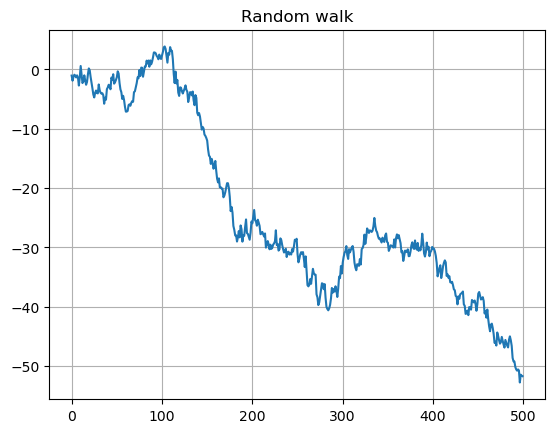

In [1]:
#Example
## Random walk
import numpy as np
import matplotlib.pyplot as plt
n=500
z=np.random.normal(0,1,n)
x=np.cumsum(z)
plt.plot(x)
plt.title('Random walk')
plt.grid()
plt.show()

In many real systems we observe vectors:

$$
\mathbf{X}_t =
\begin{pmatrix}
X_{1t} \\
X_{2t} \\
\vdots \\
X_{kt}
\end{pmatrix}
$$

Examples:

- Macroeconomics: inflation, GDP, interest rate  
- Environmental systems: PM10, PM2.5, temperature  
- Finance: returns of multiple assets  
- Neuroscience: multichannel EEG signals  

Key Question:

> How do we model dynamic dependence between variables and across time simultaneously?





---
# Multivariate Time Series

A **k-dimensional time series** is a sequence:

$$
\{\mathbf{X}_t\}_{t \in \mathbb{Z}}
$$

where:

$$
\mathbf{X}_t \in \mathbb{R}^k
$$

---

# Weak Stationarity

A multivariate process is **weakly stationary** if:

1. Constant Mean

$$
E(\mathbf{X}_t) = \boldsymbol{\mu}
$$

2. Covariance depends only on lag

$$
\Gamma(h) = \text{Cov}(\mathbf{X}_{t+h}, \mathbf{X}_t)
$$

where

$$
\Gamma(h) = E\left[(\mathbf{X}_{t+h}-\mu)(\mathbf{X}_t-\mu)'\right]
$$

Important:

$\Gamma(h)$ is a $k \times k$ matrix such that $\Gamma(-h) = \Gamma(h)'$  

# Autocovariance and Autocorrelation Matrices

Autocovariance matrix:

$$
\Gamma(h)
$$

Autocorrelation matrix:

$$
R(h) = D^{-1/2}\Gamma(h)D^{-1/2}
$$

where

$$
D = \text{diag}(\Gamma(0))
$$

Interpretation:

- Diagonal entries → autocorrelation of each series  
- Off-diagonal entries → cross-correlations

**Note**: Time series analysis studies
- Dependence across time
- Dependence across time
- 
Autocorrelation is the mathematical tool that quantifies this dependence.

In [2]:
#yfinance
import yfinance as yf
import pandas as pd 

tickers=['AAPL','MSFT','GOOGL']

data=yf.download(tickers,'2022-01-01','2024-01-01')['Close']
data

/tmp/ipykernel_35911/1231325658.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data=yf.download(tickers,'2022-01-01','2024-01-01')['Close']
[*********************100%***********************]  3 of 3 completed


Ticker,AAPL,GOOGL,MSFT
Date,,,
2022-01-03,178.103638,143.904205,323.898315
2022-01-04,175.843231,143.316650,318.344482
2022-01-05,171.165802,136.741821,306.123871
2022-01-06,168.308487,136.714508,303.704926
2022-01-07,168.474854,135.989487,303.859772
...,...,...,...
2023-12-22,191.609482,140.428955,369.077087
2023-12-26,191.065125,140.458740,369.155914
2023-12-27,191.164062,139.317368,368.574585


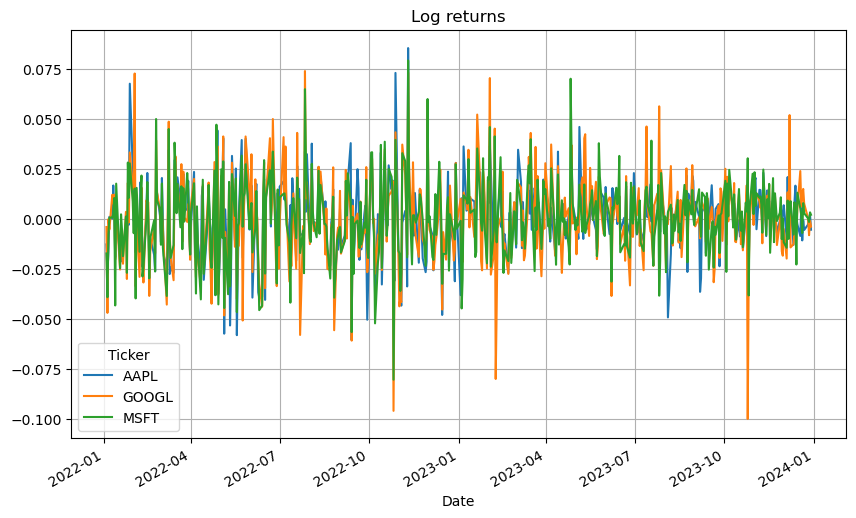

In [3]:
returns=np.log(data).diff().dropna()
returns.plot(figsize=(10,6))
plt.title('Log returns')
plt.grid()
plt.show()

In [4]:
#Determinnnig stationarity 
from statsmodels.tsa.stattools import adfuller

for ticker in tickers:
    print(f'\nADF test for {ticker}:')
    result=adfuller(returns[ticker])
    print('\nADF Statistic: %f' % result[0])
    print('\np-value: %f' % result[1])    
    print('\nIs stationary?', result[1] < 0.05)


ADF test for AAPL:

ADF Statistic: -16.893571

p-value: 0.000000

Is stationary? True

ADF test for MSFT:

ADF Statistic: -14.863024

p-value: 0.000000

Is stationary? True

ADF test for GOOGL:

ADF Statistic: -22.249993

p-value: 0.000000

Is stationary? True


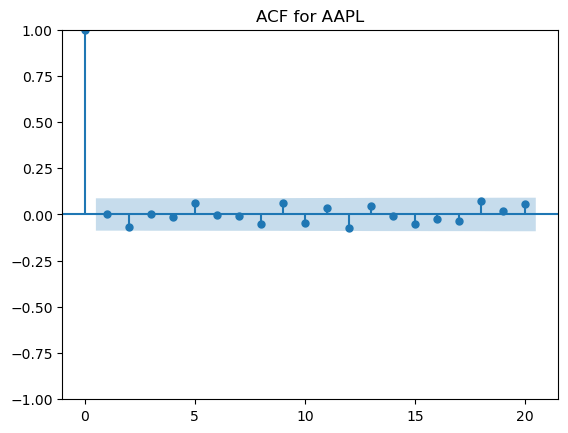

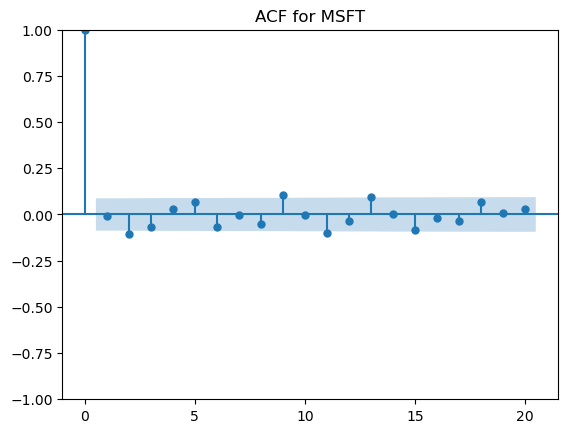

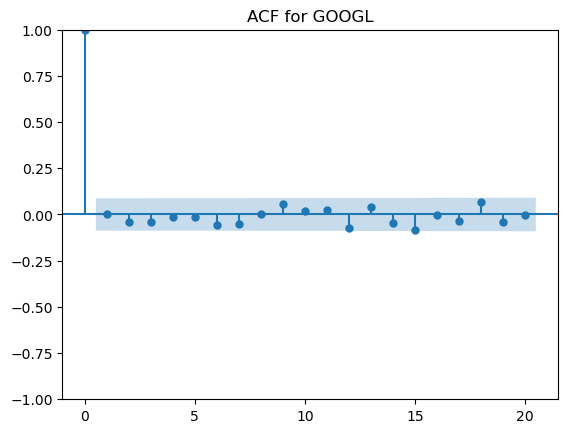

In [5]:
#ACF 
from statsmodels.graphics.tsaplots import plot_acf
for ticker in tickers:
    plot_acf(returns[ticker], lags=20, title=f'ACF for {ticker}')
    plt.show()
    

## Exercises

1. Prove that $\Gamma(-h)=\Gamma(h)^T$.
2. Compute aucovariance for a time series.



### Demostración:  $\Gamma(-h) = \Gamma(h)^\top$

Sea \(\{X_t\}\) un proceso estocástico multivariado estacionario de dimensión \(k\), con:

$$
\mu = \mathbb{E}[X_t]
$$

La función de autocovarianza en el rezago \(h\) se define como:

$$
\Gamma(h) = \mathbb{E}\left[(X_t - \mu)(X_{t-h} - \mu)^\top \right]
$$

---

### Queremos demostrar:

$$
\Gamma(-h) = \Gamma(h)^\top
$$

---

Por definición:

$$
\Gamma(-h) = \mathbb{E}\left[(X_t - \mu)(X_{t+h} - \mu)^\top \right]
$$

---
Podemos cambiar el índice temporal:

Sea $s = t + h$, entonces $t = s - h$.

Sustituyendo:

$$
\Gamma(-h) = \mathbb{E}\left[(X_{s-h} - \mu)(X_s - \mu)^\top \right]
$$

---

Recordemos la definición de $\Gamma(h)$:

$$
\Gamma(h) = \mathbb{E}\left[(X_s - \mu)(X_{s-h} - \mu)^\top \right]
$$

Ahora tomamos la transpuesta:

$$
\Gamma(h)^\top 
=
\left(
\mathbb{E}\left[(X_s - \mu)(X_{s-h} - \mu)^\top \right]
\right)^\top
$$

Usando la propiedad:

$$
(AB)^\top = B^\top A^\top
$$

tenemos:

$$
\Gamma(h)^\top
=
\mathbb{E}\left[(X_{s-h} - \mu)(X_s - \mu)^\top \right]
$$

---


Observamos que:

$$
\Gamma(-h)
=
\mathbb{E}\left[(X_{s-h} - \mu)(X_s - \mu)^\top \right]
=
\Gamma(h)^\top
$$

Por lo tanto,

$$
\boxed{
\Gamma(-h) = \Gamma(h)^\top
}
$$



In [30]:
ticker2=['BTC-USD','ETH-USD','USDT-USD']
data2=yf.download(ticker2,'2024-01-01','2025-12-31')['Close']
log_prices = np.log(data2).dropna()
print(log_prices.head())

/tmp/ipykernel_35911/1017161012.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data2=yf.download(ticker2,'2024-01-01','2025-12-31')['Close']
[*********************100%***********************]  3 of 3 completed

Ticker        BTC-USD   ETH-USD  USDT-USD
Date                                     
2024-01-01  10.695741  7.763161  0.000368
2024-01-02  10.713483  7.764651  0.000507
2024-01-03  10.665418  7.701093  0.000657
2024-01-04  10.696026  7.727111  0.001031
2024-01-05  10.695636  7.726939  0.000877


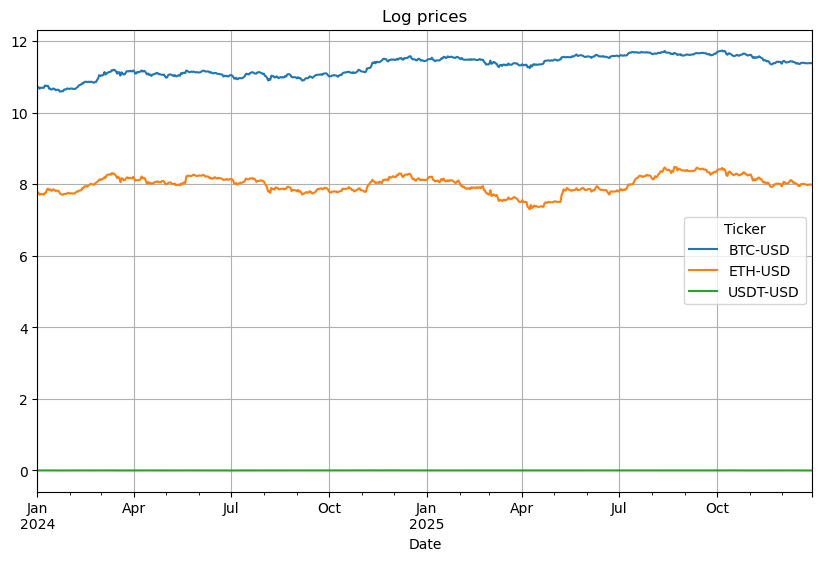

In [27]:
log_prices.plot(figsize=(10,6))
plt.title('Log prices')
plt.grid()
plt.show()

In [28]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

johan_test = coint_johansen(log_prices, det_order=0, k_ar_diff=1)

trace_stat = johan_test.lr1
critical_values = johan_test.cvt

print("Estadísticos Trace:")
print(trace_stat)

print("\nValores críticos (90%, 95%, 99%):")
print(critical_values)


Estadísticos Trace:
[79.79315458 10.76399722  1.88825761]

Valores críticos (90%, 95%, 99%):
[[27.0669 29.7961 35.4628]
 [13.4294 15.4943 19.9349]
 [ 2.7055  3.8415  6.6349]]


Matriz de autocovarianza lag 0:
[[8.08004212e-02 2.28920689e-02 2.43068523e-05]
 [2.28920689e-02 5.85695586e-02 1.90232923e-05]
 [2.43068523e-05 1.90232923e-05 2.92420731e-07]]

Matriz de autocovarianza lag 1:
[[8.02335133e-02 2.22648310e-02 2.45227777e-05]
 [2.25999115e-02 5.78675115e-02 1.97110243e-05]
 [2.12473778e-05 1.52236140e-05 2.24042867e-07]]
